# Portfolio Performance & Risk Attribution Engine

**Single-notebook public v1.0 — exact native-frequency Brinson primary**

A self-contained Python research engine for:

- absolute multi-period performance attribution;
- Brinson–Hood–Beebower and Brinson–Fachler benchmark-relative attribution;
- Carino multi-period linking;
- regression-based factor return and variance attribution;
- Euler volatility and tracking-error attribution;
- historical/scenario Expected Shortfall attribution;
- maximum-drawdown and stress-period attribution;
- hierarchical aggregation by portfolio classifications;
- reconciliation and meaning-level release checks.

The notebook intentionally focuses on the **stable attribution core**. It does not attempt to be a complete institutional attribution platform, a portfolio optimizer, or a scenario generator.

### How to use it

1. Edit the **Configuration** cell.
2. Keep `DATA_MODE = "download"` to use real public market data via Yahoo Finance, or switch to `"csv"` for your own return/price file.
3. Press **Run All**.

There is **no synthetic fallback**: if real data are unavailable, the notebook fails visibly rather than silently replacing them.

> **Weight semantics.** Portfolio and benchmark weights are applied at the native
> return frequency. With daily returns and static target weights, this represents
> a daily constant-mix strategy. Consequently, attribution performed directly at
> the native frequency is the exact representation of the realised strategy.
> Coarser monthly Brinson views are retained only as reporting approximations
> whenever compounding first changes the economic rebalancing convention.


In [1]:
# ============================================================
# 0. SETUP
# ============================================================
import sys
import subprocess
import importlib.util
from dataclasses import dataclass
from typing import Iterable, Mapping, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

if importlib.util.find_spec("yfinance") is None:
    print("Installing yfinance once in the current Python environment...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance>=0.2.40"])

import yfinance as yf

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
np.set_printoptions(suppress=True, precision=6)

print("Environment ready.")

Environment ready.


## 1. Configuration

For a different portfolio, the main object to edit is `PORTFOLIO`.

`portfolio_weight` and `benchmark_weight` must each sum to 1. The classification columns can be changed or extended freely.

The default universe is a diversified liquid multi-asset example rather than a technology-stock exercise.

In [2]:
# ============================================================
# 1. CONFIGURATION — EDIT THIS CELL FOR YOUR PORTFOLIO
# ============================================================

DATA_MODE = "download"       # "download" or "csv"
START_DATE = "2010-01-01"
END_DATE = None              # None = latest available

# Used only when DATA_MODE == "csv".
# Expected layout: Date index + one column per ticker.
CSV_PATH = None              # e.g. r"C:\\data\\portfolio_prices.csv"
CSV_KIND = "prices"          # "prices" or "returns"

REPORTING_RULE = "ME"        # secondary Brinson reporting view; exact attribution stays native-frequency
RISK_LOOKBACK = 756          # approx. 3 trading years
ES_ALPHA = 0.975
PORTFOLIO_VALUE = 1_000_000.0

PORTFOLIO = pd.DataFrame(
    {
        "portfolio_weight": [0.42, 0.18, 0.10, 0.08, 0.05, 0.07, 0.05, 0.05],
        "benchmark_weight": [0.50, 0.20, 0.10, 0.05, 0.05, 0.05, 0.02, 0.03],
        "Asset Class": [
            "Equity", "Rates", "Credit", "Credit",
            "Real Assets", "Real Assets", "Real Assets", "Cash"
        ],
        "Risk Sleeve": [
            "Growth", "Duration", "Duration", "Credit",
            "Growth", "Diversifier", "Diversifier", "Liquidity"
        ],
        "Region": ["Global", "US", "US", "US", "US", "Global", "Global", "US"],
        "Currency": ["USD"] * 8,
    },
    index=["VT", "IEF", "LQD", "HYG", "VNQ", "GLD", "DBC", "BIL"],
)
PORTFOLIO.index.name = "ticker"

FACTOR_SPREADS = {
    "Equity_ex_cash": ("VT", "BIL"),
    "Duration_ex_cash": ("IEF", "BIL"),
    "Credit_ex_rates": ("HYG", "IEF"),
}

STRESS_START = None
STRESS_END = None

assert np.isclose(PORTFOLIO["portfolio_weight"].sum(), 1.0)
assert np.isclose(PORTFOLIO["benchmark_weight"].sum(), 1.0)

display(PORTFOLIO)
print("Portfolio weights sum to:", PORTFOLIO["portfolio_weight"].sum())
print("Benchmark weights sum to:", PORTFOLIO["benchmark_weight"].sum())

,portfolio_weight,benchmark_weight,Asset Class,Risk Sleeve,Region,Currency
ticker,,,,,,
VT,0.420000,0.500000,Equity,Growth,Global,USD
IEF,0.180000,0.200000,Rates,Duration,US,USD
LQD,0.100000,0.100000,Credit,Duration,US,USD
HYG,0.080000,0.050000,Credit,Credit,US,USD
VNQ,0.050000,0.050000,Real Assets,Growth,US,USD
GLD,0.070000,0.050000,Real Assets,Diversifier,Global,USD
DBC,0.050000,0.020000,Real Assets,Diversifier,Global,USD
BIL,0.050000,0.030000,Cash,Liquidity,US,USD


Portfolio weights sum to: 1.0
Benchmark weights sum to: 1.0


## 2. Attribution engine

The following cells contain the engine itself so that the notebook has **no dependency on a local project package**.

In [3]:
# ============================================================
# 2A. CORE ENGINE
# ============================================================

from dataclasses import dataclass
from typing import Iterable, Mapping, Sequence

import numpy as np
import pandas as pd


# -----------------------------------------------------------------------------
# Validation and alignment
# -----------------------------------------------------------------------------

def _as_series(x, index: pd.Index, name: str) -> pd.Series:
    if isinstance(x, pd.Series):
        out = x.astype(float).reindex(index)
    else:
        arr = np.asarray(x, dtype=float).squeeze()
        if arr.ndim != 1 or len(arr) != len(index):
            raise ValueError(f"{name} must contain one value per asset.")
        out = pd.Series(arr, index=index, name=name)
    if out.isna().any() or not np.isfinite(out.to_numpy()).all():
        raise ValueError(f"{name} contains missing or non-finite values after alignment.")
    return out.rename(name)


def validate_static_weights(
    weights,
    assets: pd.Index,
    name: str = "weights",
    tol: float = 1e-8,
) -> pd.Series:
    out = _as_series(weights, assets, name)
    if not np.isclose(out.sum(), 1.0, atol=tol):
        raise ValueError(f"{name} must sum to one; got {out.sum():.12f}.")
    return out


def normalize_probabilities(p, n: int) -> np.ndarray:
    if p is None:
        return np.full(n, 1.0 / n)
    arr = np.asarray(p, dtype=float).squeeze()
    if arr.ndim != 1 or len(arr) != n:
        raise ValueError("probabilities must have one value per observation/scenario.")
    if np.any(~np.isfinite(arr)) or np.any(arr < 0):
        raise ValueError("probabilities must be finite and non-negative.")
    total = arr.sum()
    if total <= 0:
        raise ValueError("probabilities have zero total mass.")
    return arr / total


def returns_coverage(returns: pd.DataFrame) -> pd.DataFrame:
    """Per-asset sample diagnostic: what each asset actually contributes before
    any complete-case truncation. Makes silent history loss visible."""
    raw = returns.copy().astype(float).replace([np.inf, -np.inf], np.nan)
    valid = raw.notna()
    common = raw.dropna(how="any")
    rows = {
        "first_valid": raw.apply(lambda s: s.first_valid_index()),
        "last_valid": raw.apply(lambda s: s.last_valid_index()),
        "n_valid": valid.sum(),
        "n_missing": (~valid).sum(),
        "pct_zero_returns": (raw == 0).sum() / valid.sum().replace(0, np.nan),
    }
    out = pd.DataFrame(rows)
    out["n_used_after_complete_case"] = len(common)
    out["obs_lost_to_complete_case"] = out["n_valid"] - len(common)
    return out


def align_returns(returns: pd.DataFrame, incomplete: str = "drop_dates") -> pd.DataFrame:
    """Align a return panel.

    incomplete="drop_dates" (default, legacy): complete-case. Any date with a
        missing value is dropped, which truncates the WHOLE panel to the latest
        common inception -- one late-launched asset can silently discard years
        of history for every other asset. Call ``returns_coverage`` to see the
        cost before accepting it.
    incomplete="drop_assets": keep the full date range and drop the assets that
        do not span it. Preserves history at the cost of universe breadth.
    """
    if not isinstance(returns, pd.DataFrame) or returns.empty:
        raise ValueError("returns must be a non-empty DataFrame.")
    out = returns.copy().astype(float)
    if isinstance(out.index, pd.DatetimeIndex):
        out = out.sort_index()
    out = out.replace([np.inf, -np.inf], np.nan)
    if out.columns.duplicated().any():
        raise ValueError("returns contains duplicate asset columns.")
    if incomplete == "drop_dates":
        out = out.dropna(how="any")
    elif incomplete == "drop_assets":
        keep = out.columns[out.notna().all(axis=0)]
        if len(keep) == 0:
            raise ValueError("no asset spans the full date range.")
        out = out.loc[:, keep]
    else:
        raise ValueError("incomplete must be 'drop_dates' or 'drop_assets'.")
    if out.empty:
        raise ValueError("returns are empty after handling incomplete observations.")
    return out


def prices_to_returns(prices: pd.DataFrame, missing: str = "drop") -> pd.DataFrame:
    """Convert a price/total-return-index panel to simple returns.

    missing="drop" (recommended): compute returns per asset on that asset's own
        observed prices, leaving genuine gaps as NaN.
    missing="ffill_prices": forward-fill prices first. NOTE this injects a
        ZERO return on every filled day, which deflates realised volatility,
        tracking error and ES, and distorts autocorrelation -- the very
        quantities a risk engine decomposes. Offered for parity with legacy
        pipelines, not recommended.
    """
    px = prices.copy().astype(float).sort_index()
    if missing == "ffill_prices":
        px = px.ffill()
    elif missing != "drop":
        raise ValueError("missing must be 'drop' or 'ffill_prices'.")
    return px.pct_change(fill_method=None).iloc[1:]


def expand_weights(
    weights: pd.Series | pd.DataFrame | Sequence[float],
    returns: pd.DataFrame,
    name: str,
) -> pd.DataFrame:
    assets = returns.columns
    if isinstance(weights, pd.DataFrame):
        w = weights.copy().astype(float)
        w.index = pd.to_datetime(w.index)
        w = w.reindex(columns=assets)
        w = w.reindex(returns.index, method="ffill")
        if w.isna().any().any():
            raise ValueError(f"{name} does not cover the full return history.")
        row_sums = w.sum(axis=1)
        if not np.allclose(row_sums, 1.0, atol=1e-8):
            raise ValueError(f"Each row of {name} must sum to one.")
        return w
    static = validate_static_weights(weights, assets, name)
    return pd.DataFrame(
        np.repeat(static.to_numpy()[None, :], len(returns), axis=0),
        index=returns.index,
        columns=assets,
    )


def compound_returns(returns: pd.DataFrame | pd.Series, rule: str) -> pd.DataFrame | pd.Series:
    if not isinstance(returns.index, pd.DatetimeIndex):
        raise TypeError("Multi-period compounding requires a DatetimeIndex.")
    return (1.0 + returns).resample(rule).prod() - 1.0


def compound_spread(
    long_returns: pd.DataFrame | pd.Series,
    short_returns: pd.DataFrame | pd.Series,
    rule: str,
) -> pd.DataFrame | pd.Series:
    """Correctly compounded long-short factor: compound each leg, then
    difference.

    The naive route -- building the daily spread ``long - short`` and
    compounding it -- is wrong: prod(1 + (l_t - s_t)) - 1 is not the return of
    any tradable long-short position, and the error grows with horizon and
    volatility. This helper produces the period factor a funded long/short
    portfolio actually earns.
    """
    return compound_returns(long_returns, rule) - compound_returns(short_returns, rule)


def link_additive_components(
    components: pd.DataFrame,
    portfolio_returns: pd.Series | None = None,
) -> tuple[pd.Series, pd.Series]:
    """Link ANY per-period additive decomposition of the portfolio return.

    ``components`` is a (periods x parts) frame whose rows sum to the
    portfolio period return (pass ``portfolio_returns`` to assert this against
    an external series). Each period's parts are grown by subsequent portfolio
    growth -- the same telescoping identity as ``geometric_asset_linking`` --
    so linked parts sum exactly to the cumulative return. Reused by the
    Campisi fixed-income and Karnosky-Singer currency modules.
    """
    c = components.astype(float)
    rp = c.sum(axis=1)
    if portfolio_returns is not None:
        ext = pd.Series(portfolio_returns, dtype=float).reindex(c.index)
        gap = float((rp - ext).abs().max())
        if not np.isfinite(gap) or gap > 1e-10:
            raise ValueError(
                f"components do not sum to the supplied portfolio returns "
                f"(max gap {gap:.3e})."
            )
    if (1.0 + rp <= 0).any():
        raise ValueError("Linking requires period returns greater than -100%.")
    future_growth = (1.0 + rp.iloc[::-1]).cumprod().iloc[::-1] / (1.0 + rp)
    linked = c.mul(future_growth, axis=0).sum(axis=0)
    cumulative = float((1.0 + rp).prod() - 1.0)
    check = pd.Series({
        "cumulative_portfolio_return": cumulative,
        "sum_linked_components": float(linked.sum()),
        "linking_error": float(linked.sum() - cumulative),
    }, name="link_additive_components_check")
    return linked, check


def period_start_weights(weights: pd.DataFrame, period_returns: pd.DataFrame) -> pd.DataFrame:
    """Weight in force at the START of each reporting period.

    For the period ending at ``period_returns.index[i]`` the window is
    ``(index[i-1], index[i]]``; this returns the FIRST weight observation
    inside that window, i.e. the allocation the portfolio entered the period
    with -- which is what generated that period's return.

    Prior versions of this function forward-filled onto the period-end label
    and therefore returned the CLOSING weight. Under intra-period rebalancing
    that attributes a period's return to the post-rebalance allocation, which
    can be badly wrong while every reconciliation identity still closes
    exactly. See ``period_end_weights`` for the legacy behaviour.
    """
    if not isinstance(weights.index, pd.DatetimeIndex):
        raise TypeError("weights must have a DatetimeIndex.")
    if not isinstance(period_returns.index, pd.DatetimeIndex):
        raise TypeError("period_returns must have a DatetimeIndex.")

    idx = weights.index.to_numpy()
    ends = period_returns.index.to_numpy()
    # Lower bound of each window: previous period end (exclusive); for the
    # first period, anything strictly before the first weight observation.
    prev = np.empty(len(ends), dtype=idx.dtype)
    if len(ends):
        prev[0] = idx[0] - np.timedelta64(1, "ns")
        prev[1:] = ends[:-1]
    pos = np.searchsorted(idx, prev, side="right")
    pos = np.clip(pos, 0, len(idx) - 1)
    out = weights.iloc[pos].copy()
    out.index = period_returns.index
    return out


def period_end_weights(weights: pd.DataFrame, period_returns: pd.DataFrame) -> pd.DataFrame:
    """Legacy behaviour: last known weight at or before each period end."""
    return weights.reindex(period_returns.index, method="ffill")


def detect_intra_period_rebalancing(weights: pd.DataFrame, rule: str) -> bool:
    """True if the weights change anywhere inside a reporting period, in which
    case single-weight period attribution is an approximation regardless of
    which end of the period the weight is taken from."""
    if not isinstance(weights.index, pd.DatetimeIndex) or len(weights) < 2:
        return False
    changed = weights.diff().abs().sum(axis=1) > 1e-12
    if not changed.any():
        return False
    grouper = weights.index.to_series().resample(rule)
    first_of_period = grouper.transform("min")
    # A change on the first observation of a period is a period-boundary
    # rebalance; anything else is intra-period.
    return bool((changed & (weights.index.to_series() != first_of_period)).any())


# -----------------------------------------------------------------------------
# Weighted distribution helpers
# -----------------------------------------------------------------------------

def weighted_mean(x, p):
    arr = np.asarray(x, dtype=float)
    p = normalize_probabilities(p, arr.shape[0])
    shape = (-1,) + (1,) * (arr.ndim - 1)
    return np.sum(arr * p.reshape(shape), axis=0)


def weighted_cov(x, p):
    arr = np.asarray(x, dtype=float)
    if arr.ndim == 1:
        arr = arr[:, None]
    p = normalize_probabilities(p, arr.shape[0])
    mu = weighted_mean(arr, p)
    centered = arr - mu
    return (centered * p[:, None]).T @ centered


def weighted_quantile(x, p, alpha: float) -> float:
    arr = np.asarray(x, dtype=float).squeeze()
    p = normalize_probabilities(p, len(arr))
    order = np.argsort(arr)
    xs = arr[order]
    ps = p[order]
    return float(xs[np.searchsorted(np.cumsum(ps), alpha, side="left")])


def expected_shortfall_tail_weights(losses, p, alpha: float) -> tuple[float, float, np.ndarray]:
    """Exact discrete ES weights for the worst (1-alpha) probability mass."""
    losses = np.asarray(losses, dtype=float).squeeze()
    p = normalize_probabilities(p, len(losses))
    if not 0 < alpha < 1:
        raise ValueError("alpha must lie strictly between zero and one.")

    var = weighted_quantile(losses, p, alpha)
    tail_mass = 1.0 - alpha
    order = np.argsort(losses)[::-1]
    weights = np.zeros_like(p)
    remaining = tail_mass
    for j in order:
        if remaining <= 1e-15:
            break
        take = min(p[j], remaining)
        weights[j] = take
        remaining -= take
    if weights.sum() <= 0:
        raise RuntimeError("Unable to construct Expected Shortfall tail weights.")
    weights /= weights.sum()
    es = float(weights @ losses)
    return var, es, weights


# -----------------------------------------------------------------------------
# Performance attribution
# -----------------------------------------------------------------------------

def single_period_asset_attribution(weights, asset_returns) -> tuple[pd.DataFrame, pd.Series]:
    r = pd.Series(asset_returns, dtype=float)
    w = validate_static_weights(weights, r.index, "portfolio_weights")
    contrib = w * r
    rp = float(contrib.sum())
    table = pd.DataFrame({
        "weight": w,
        "asset_return": r,
        "return_contribution": contrib,
    })
    table["pct_of_portfolio_return"] = np.where(
        abs(rp) > 1e-14, table["return_contribution"] / rp, np.nan
    )
    check = pd.Series({
        "portfolio_return": rp,
        "sum_contributions": table["return_contribution"].sum(),
        "additivity_error": table["return_contribution"].sum() - rp,
    }, name="single_period_asset_check")
    return table, check


def geometric_asset_linking(
    returns: pd.DataFrame,
    weights: pd.Series | pd.DataFrame | Sequence[float],
) -> tuple[pd.DataFrame, pd.Series]:
    """Exact multi-period linking of absolute asset return contributions.

    Period contribution w_t,i r_t,i is multiplied by subsequent portfolio growth,
    so linked contributions sum exactly to the cumulative portfolio return.
    """
    r = align_returns(returns)
    w = expand_weights(weights, r, "portfolio_weights")
    period_contrib = w * r
    rp = period_contrib.sum(axis=1)
    if (1.0 + rp <= 0).any():
        raise ValueError("Geometric linking requires portfolio period returns greater than -100%.")
    future_growth = (1.0 + rp.iloc[::-1]).cumprod().iloc[::-1] / (1.0 + rp)
    linked_by_period_asset = period_contrib.mul(future_growth, axis=0)
    linked_asset = linked_by_period_asset.sum(axis=0)
    cumulative_return = float((1.0 + rp).prod() - 1.0)
    table = pd.DataFrame({
        "linked_return_contribution": linked_asset,
        "pct_of_cumulative_portfolio_return": np.where(
            abs(cumulative_return) > 1e-14,
            linked_asset / cumulative_return,
            np.nan,
        ),
    })
    check = pd.Series({
        "cumulative_portfolio_return": cumulative_return,
        "sum_linked_asset_contributions": linked_asset.sum(),
        "linking_error": linked_asset.sum() - cumulative_return,
    }, name="geometric_asset_linking_check")
    return table, check


# -----------------------------------------------------------------------------
# Brinson attribution
# -----------------------------------------------------------------------------

def _classification_series(classifications, assets: pd.Index, level: str) -> pd.Series:
    if isinstance(classifications, pd.DataFrame):
        if level not in classifications.columns:
            raise KeyError(f"Classification level '{level}' not found.")
        groups = classifications[level].reindex(assets)
    elif isinstance(classifications, pd.Series):
        groups = classifications.reindex(assets)
    elif isinstance(classifications, Mapping):
        groups = pd.Series(classifications).reindex(assets)
    else:
        groups = pd.Series(classifications, index=assets)
    if groups.isna().any():
        missing = groups.index[groups.isna()].tolist()
        raise ValueError(f"Missing classification for assets: {missing}")
    return groups.astype(str)


def brinson_single_period(
    portfolio_weights,
    benchmark_weights,
    asset_returns,
    classifications,
    level: str = "Asset Class",
    method: str = "BF",
) -> tuple[pd.DataFrame, pd.Series]:
    r = pd.Series(asset_returns, dtype=float)
    assets = r.index
    wp = validate_static_weights(portfolio_weights, assets, "portfolio_weights")
    wb = validate_static_weights(benchmark_weights, assets, "benchmark_weights")
    groups = _classification_series(classifications, assets, level)

    rp_total = float(wp @ r)
    rb_total = float(wb @ r)
    rows = []
    for group in pd.Index(groups.unique()):
        mask = groups == group
        wp_g = float(wp[mask].sum())
        wb_g = float(wb[mask].sum())
        rp_g = float((wp[mask] @ r[mask]) / wp_g) if abs(wp_g) > 1e-15 else 0.0
        rb_g = float((wb[mask] @ r[mask]) / wb_g) if abs(wb_g) > 1e-15 else 0.0
        if method.upper() == "BHB":
            allocation = (wp_g - wb_g) * rb_g
        elif method.upper() == "BF":
            allocation = (wp_g - wb_g) * (rb_g - rb_total)
        else:
            raise ValueError("method must be 'BHB' or 'BF'.")
        selection = wb_g * (rp_g - rb_g)
        interaction = (wp_g - wb_g) * (rp_g - rb_g)
        rows.append({
            level: group,
            "portfolio_weight": wp_g,
            "benchmark_weight": wb_g,
            "portfolio_group_return": rp_g,
            "benchmark_group_return": rb_g,
            "allocation_effect": allocation,
            "selection_effect": selection,
            "interaction_effect": interaction,
            "total_effect": allocation + selection + interaction,
        })
    table = pd.DataFrame(rows).set_index(level)
    active = rp_total - rb_total
    check = pd.Series({
        "portfolio_return": rp_total,
        "benchmark_return": rb_total,
        "active_return": active,
        "sum_attribution_effects": table["total_effect"].sum(),
        "additivity_error": table["total_effect"].sum() - active,
    }, name=f"brinson_{method.upper()}_{level}_check")
    return table, check


def carino_link(
    period_effects: pd.DataFrame,
    portfolio_returns: pd.Series,
    benchmark_returns: pd.Series,
) -> tuple[pd.Series, pd.Series]:
    effects = period_effects.astype(float)
    rp = pd.Series(portfolio_returns, dtype=float).reindex(effects.index)
    rb = pd.Series(benchmark_returns, dtype=float).reindex(effects.index)
    if rp.isna().any() or rb.isna().any():
        raise ValueError("Return series and attribution effects must share the same index.")
    if ((1 + rp) <= 0).any() or ((1 + rb) <= 0).any():
        raise ValueError("Carino linking requires period returns greater than -100%.")

    diff = rp - rb
    k_t = pd.Series(index=effects.index, dtype=float)
    near = diff.abs() < 1e-14
    k_t.loc[near] = 1.0 / (1.0 + rp.loc[near])
    k_t.loc[~near] = (
        np.log1p(rp.loc[~near]) - np.log1p(rb.loc[~near])
    ) / diff.loc[~near]

    Rp = float((1.0 + rp).prod() - 1.0)
    Rb = float((1.0 + rb).prod() - 1.0)
    active = Rp - Rb
    if abs(active) < 1e-14:
        K = 1.0 / (1.0 + Rp)
    else:
        K = (np.log1p(Rp) - np.log1p(Rb)) / active

    linked = effects.mul(k_t / K, axis=0).sum(axis=0)
    check = pd.Series({
        "cumulative_portfolio_return": Rp,
        "cumulative_benchmark_return": Rb,
        "cumulative_active_return": active,
        "sum_linked_effects": linked.sum(),
        "linking_error": linked.sum() - active,
    }, name="carino_linking_check")
    return linked, check


def _brinson_panel(
    period_returns: pd.DataFrame,
    portfolio_weights,
    benchmark_weights,
    classifications,
    level: str,
    method: str,
):
    """Vectorised Brinson over all periods at once.

    Group aggregation is a one-hot matrix multiply: with G the (assets x
    groups) indicator, group weights are W = w @ G and group returns are
    (w * r) @ G / W, guarded exactly like the single-period reference. All
    effect formulas are then elementwise over the (periods x groups) arrays.
    Replaces the per-date Python loop (kept as
    ``brinson_multi_period_reference`` and pinned equal by tests).
    """
    method = method.upper()
    if method not in ("BF", "BHB"):
        raise ValueError("method must be 'BHB' or 'BF'.")
    r = align_returns(period_returns)
    wp = expand_weights(portfolio_weights, r, "portfolio_weights")
    wb = expand_weights(benchmark_weights, r, "benchmark_weights")
    groups = _classification_series(classifications, r.columns, level)
    labels = pd.Index(groups.unique(), name=level)
    G = (groups.to_numpy()[:, None] == labels.to_numpy()[None, :]).astype(float)

    R, WP, WB = r.to_numpy(), wp.to_numpy(), wb.to_numpy()
    Wp = WP @ G
    Wb = WB @ G
    Np = (WP * R) @ G
    Nb = (WB * R) @ G
    with np.errstate(divide="ignore", invalid="ignore"):
        rp_g = np.where(np.abs(Wp) > 1e-15, Np / np.where(Wp == 0, 1, Wp), 0.0)
        rb_g = np.where(np.abs(Wb) > 1e-15, Nb / np.where(Wb == 0, 1, Wb), 0.0)
    rp_tot = (WP * R).sum(axis=1)
    rb_tot = (WB * R).sum(axis=1)

    if method == "BHB":
        alloc = (Wp - Wb) * rb_g
    else:
        alloc = (Wp - Wb) * (rb_g - rb_tot[:, None])
    sel = Wb * (rp_g - rb_g)
    inter = (Wp - Wb) * (rp_g - rb_g)

    idx = pd.MultiIndex.from_product([r.index, labels], names=["date", level])
    detailed = pd.DataFrame({
        "portfolio_weight": Wp.ravel(),
        "benchmark_weight": Wb.ravel(),
        "portfolio_group_return": rp_g.ravel(),
        "benchmark_group_return": rb_g.ravel(),
        "allocation_effect": alloc.ravel(),
        "selection_effect": sel.ravel(),
        "interaction_effect": inter.ravel(),
    }, index=idx)
    detailed["total_effect"] = (detailed["allocation_effect"]
                                + detailed["selection_effect"]
                                + detailed["interaction_effect"])
    period_effects = pd.DataFrame({
        "allocation_effect": alloc.sum(axis=1),
        "selection_effect": sel.sum(axis=1),
        "interaction_effect": inter.sum(axis=1),
    }, index=r.index)
    rp = pd.Series(rp_tot, index=r.index, name="portfolio_return")
    rb = pd.Series(rb_tot, index=r.index, name="benchmark_return")
    return detailed, period_effects, rp, rb


def brinson_multi_period(
    period_returns: pd.DataFrame,
    portfolio_weights: pd.Series | pd.DataFrame | Sequence[float],
    benchmark_weights: pd.Series | pd.DataFrame | Sequence[float],
    classifications,
    level: str = "Asset Class",
    method: str = "BF",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    detailed, period_effects, rp, rb = _brinson_panel(
        period_returns, portfolio_weights, benchmark_weights,
        classifications, level, method,
    )
    linked, check = carino_link(period_effects, rp, rb)
    summary = linked.to_frame("linked_effect")
    summary["pct_of_cumulative_active_return"] = np.where(
        abs(check["cumulative_active_return"]) > 1e-14,
        summary["linked_effect"] / check["cumulative_active_return"],
        np.nan,
    )
    return detailed, summary, check


def brinson_multi_period_reference(
    period_returns: pd.DataFrame,
    portfolio_weights: pd.Series | pd.DataFrame | Sequence[float],
    benchmark_weights: pd.Series | pd.DataFrame | Sequence[float],
    classifications,
    level: str = "Asset Class",
    method: str = "BF",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    """Original per-date loop. Retained as the parity reference for the
    vectorised implementation; do not use on large books."""
    r = align_returns(period_returns)
    wp = expand_weights(portfolio_weights, r, "portfolio_weights")
    wb = expand_weights(benchmark_weights, r, "benchmark_weights")

    period_group_tables = []
    period_total_effects = []
    rp = []
    rb = []
    for date in r.index:
        table, check = brinson_single_period(
            wp.loc[date], wb.loc[date], r.loc[date], classifications, level, method
        )
        tmp = table.copy()
        tmp.insert(0, "date", date)
        period_group_tables.append(tmp.reset_index())
        period_total_effects.append({
            "date": date,
            "allocation_effect": table["allocation_effect"].sum(),
            "selection_effect": table["selection_effect"].sum(),
            "interaction_effect": table["interaction_effect"].sum(),
        })
        rp.append(check["portfolio_return"])
        rb.append(check["benchmark_return"])

    detailed = pd.concat(period_group_tables, ignore_index=True).set_index(["date", level])
    period_effects = pd.DataFrame(period_total_effects).set_index("date")
    rp = pd.Series(rp, index=r.index, name="portfolio_return")
    rb = pd.Series(rb, index=r.index, name="benchmark_return")
    linked, check = carino_link(period_effects, rp, rb)

    summary = linked.to_frame("linked_effect")
    summary["pct_of_cumulative_active_return"] = np.where(
        abs(check["cumulative_active_return"]) > 1e-14,
        summary["linked_effect"] / check["cumulative_active_return"],
        np.nan,
    )
    return detailed, summary, check


# -----------------------------------------------------------------------------
# Factor attribution
# -----------------------------------------------------------------------------

def factor_regression_attribution(
    portfolio_returns: pd.Series,
    factor_returns: pd.DataFrame,
    probabilities=None,
) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    joined = pd.concat(
        [pd.Series(portfolio_returns, name="portfolio"), factor_returns], axis=1
    ).dropna()
    y = joined["portfolio"].to_numpy(dtype=float)
    F = joined.drop(columns="portfolio").to_numpy(dtype=float)
    names = joined.drop(columns="portfolio").columns
    p = normalize_probabilities(probabilities, len(joined))

    X = np.column_stack([np.ones(len(joined)), F])
    sw = np.sqrt(p)
    coef, *_ = np.linalg.lstsq(X * sw[:, None], y * sw, rcond=None)
    alpha = float(coef[0])
    beta = coef[1:]
    fitted = X @ coef
    residual = y - fitted

    factor_means = weighted_mean(F, p)
    return_contrib = beta * factor_means
    residual_mean = float(weighted_mean(residual, p))
    portfolio_mean = float(weighted_mean(y, p))

    factor_cov = weighted_cov(F, p)
    component_factor_variance = beta * (factor_cov @ beta)
    residual_variance = float(weighted_mean(residual ** 2, p))
    portfolio_variance = float(weighted_mean((y - portfolio_mean) ** 2, p))

    rows = []
    for i, name in enumerate(names):
        rows.append({
            "component": name,
            "beta": beta[i],
            "mean_factor_return": factor_means[i],
            "expected_return_contribution": return_contrib[i],
            "component_factor_variance": component_factor_variance[i],
        })
    rows += [
        {
            "component": "intercept_alpha",
            "beta": np.nan,
            "mean_factor_return": np.nan,
            "expected_return_contribution": alpha,
            "component_factor_variance": 0.0,
        },
        {
            "component": "residual",
            "beta": np.nan,
            "mean_factor_return": np.nan,
            "expected_return_contribution": residual_mean,
            "component_factor_variance": residual_variance,
        },
    ]
    table = pd.DataFrame(rows).set_index("component")
    explained = float(weighted_mean((fitted - weighted_mean(fitted, p)) ** 2, p))
    r2 = 1.0 - residual_variance / portfolio_variance if portfolio_variance > 0 else np.nan
    check = pd.Series({
        "expected_portfolio_return": portfolio_mean,
        "sum_expected_return_contributions": table["expected_return_contribution"].sum(),
        "return_additivity_error": table["expected_return_contribution"].sum() - portfolio_mean,
        "portfolio_variance": portfolio_variance,
        "explained_factor_variance": explained,
        "residual_variance": residual_variance,
        "sum_variance_components": table["component_factor_variance"].sum(),
        "variance_reconciliation_error": table["component_factor_variance"].sum() - portfolio_variance,
        "weighted_R2": r2,
    }, name="factor_attribution_check")
    residual_series = pd.Series(residual, index=joined.index, name="factor_residual")
    return table, check, residual_series


# -----------------------------------------------------------------------------
# Risk attribution
# -----------------------------------------------------------------------------

def volatility_attribution(
    returns: pd.DataFrame,
    weights,
    probabilities=None,
) -> tuple[pd.DataFrame, pd.Series]:
    r = align_returns(returns)
    w = validate_static_weights(weights, r.columns, "portfolio_weights")
    p = normalize_probabilities(probabilities, len(r))
    cov = weighted_cov(r.to_numpy(), p)
    variance = float(w.to_numpy() @ cov @ w.to_numpy())
    volatility = np.sqrt(max(variance, 0.0))
    component_variance = w.to_numpy() * (cov @ w.to_numpy())
    component_vol = component_variance / volatility if volatility > 0 else np.nan
    table = pd.DataFrame({
        "weight": w,
        "component_variance": component_variance,
        "component_volatility": component_vol,
        "pct_of_portfolio_volatility": component_vol / volatility if volatility > 0 else np.nan,
    }, index=r.columns)
    check = pd.Series({
        "portfolio_variance": variance,
        "portfolio_volatility": volatility,
        "sum_component_variance": component_variance.sum(),
        "variance_additivity_error": component_variance.sum() - variance,
        "sum_component_volatility": np.nansum(component_vol),
        "volatility_additivity_error": np.nansum(component_vol) - volatility,
    }, name="volatility_attribution_check")
    return table, check


def tracking_error_attribution(
    returns: pd.DataFrame,
    portfolio_weights,
    benchmark_weights,
    probabilities=None,
) -> tuple[pd.DataFrame, pd.Series]:
    r = align_returns(returns)
    wp = validate_static_weights(portfolio_weights, r.columns, "portfolio_weights")
    wb = validate_static_weights(benchmark_weights, r.columns, "benchmark_weights")
    active_w = wp - wb
    p = normalize_probabilities(probabilities, len(r))
    cov = weighted_cov(r.to_numpy(), p)
    te2 = float(active_w.to_numpy() @ cov @ active_w.to_numpy())
    te = np.sqrt(max(te2, 0.0))
    component_te2 = active_w.to_numpy() * (cov @ active_w.to_numpy())
    component_te = component_te2 / te if te > 0 else np.nan
    table = pd.DataFrame({
        "portfolio_weight": wp,
        "benchmark_weight": wb,
        "active_weight": active_w,
        "component_tracking_error_variance": component_te2,
        "component_tracking_error": component_te,
        "pct_of_tracking_error": component_te / te if te > 0 else np.nan,
    }, index=r.columns)
    check = pd.Series({
        "tracking_error_variance": te2,
        "tracking_error": te,
        "sum_component_TE_variance": component_te2.sum(),
        "TE_variance_additivity_error": component_te2.sum() - te2,
        "sum_component_tracking_error": np.nansum(component_te),
        "tracking_error_additivity_error": np.nansum(component_te) - te,
    }, name="tracking_error_attribution_check")
    return table, check


def expected_shortfall_attribution(
    returns: pd.DataFrame,
    weights,
    alpha: float = 0.95,
    probabilities=None,
    portfolio_value: float = 1.0,
) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    r = align_returns(returns)
    w = validate_static_weights(weights, r.columns, "portfolio_weights")
    p = normalize_probabilities(probabilities, len(r))
    asset_loss = -r.mul(w, axis=1) * float(portfolio_value)
    portfolio_loss = asset_loss.sum(axis=1)
    var, es, tail_w = expected_shortfall_tail_weights(portfolio_loss.to_numpy(), p, alpha)
    component = tail_w @ asset_loss.to_numpy()
    table = pd.DataFrame({
        "weight": w,
        "component_ES": component,
        "component_ES_pct": component / es if abs(es) > 1e-14 else np.nan,
    }, index=r.columns)
    check = pd.Series({
        "confidence_level": alpha,
        "VaR": var,
        "Expected_Shortfall": es,
        "sum_component_ES": component.sum(),
        "additivity_error": component.sum() - es,
        "tail_probability_mass": 1.0 - alpha,
        "positive_tail_weight_observations": int((tail_w > 0).sum()),
    }, name="expected_shortfall_attribution_check")
    tail_weights = pd.Series(tail_w, index=r.index, name="ES_tail_weight")
    return table, check, tail_weights


def stress_period_attribution(
    returns: pd.DataFrame,
    weights,
    start,
    end,
) -> tuple[pd.DataFrame, pd.Series]:
    r = align_returns(returns).loc[pd.Timestamp(start): pd.Timestamp(end)]
    if r.empty:
        raise ValueError("No observations fall inside the requested stress period.")
    table, check = geometric_asset_linking(r, weights)
    table = table.rename(columns={
        "linked_return_contribution": "stress_period_return_contribution",
        "pct_of_cumulative_portfolio_return": "pct_of_stress_period_return",
    })
    check = check.rename({
        "cumulative_portfolio_return": "stress_period_portfolio_return",
        "sum_linked_asset_contributions": "sum_stress_period_contributions",
    })
    return table, check


def max_drawdown_attribution(
    returns: pd.DataFrame,
    weights,
) -> tuple[pd.DataFrame, pd.Series]:
    r = align_returns(returns)
    w = expand_weights(weights, r, "portfolio_weights")
    rp = (w * r).sum(axis=1)
    wealth = (1.0 + rp).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1.0
    trough = drawdown.idxmin()
    peak = wealth.loc[:trough].idxmax()
    # Wealth at `peak` already includes the return observed on the peak date.
    # The drawdown episode therefore starts with the next observation.
    peak_pos = r.index.get_loc(peak)
    trough_pos = r.index.get_loc(trough)
    episode = r.iloc[peak_pos + 1: trough_pos + 1]
    episode_w = w.iloc[peak_pos + 1: trough_pos + 1]
    if episode.empty:
        table = pd.DataFrame({
            "drawdown_contribution": np.zeros(len(r.columns)),
            "pct_of_max_drawdown": np.nan,
        }, index=r.columns)
        check = pd.Series({
            "peak_date": peak,
            "trough_date": trough,
            "maximum_drawdown": 0.0,
            "sum_drawdown_contributions": 0.0,
            "additivity_error": 0.0,
            "episode_cumulative_return": 0.0,
        }, name="max_drawdown_attribution_check")
        return table, check
    linked, link_check = geometric_asset_linking(episode, episode_w)
    table = pd.DataFrame({
        "drawdown_contribution": -linked["linked_return_contribution"],
    })
    max_dd = float(-drawdown.loc[trough])
    table["pct_of_max_drawdown"] = np.where(
        max_dd > 1e-14, table["drawdown_contribution"] / max_dd, np.nan
    )
    check = pd.Series({
        "peak_date": peak,
        "trough_date": trough,
        "maximum_drawdown": max_dd,
        "sum_drawdown_contributions": table["drawdown_contribution"].sum(),
        "additivity_error": table["drawdown_contribution"].sum() - max_dd,
        "episode_cumulative_return": link_check["cumulative_portfolio_return"],
    }, name="max_drawdown_attribution_check")
    return table, check


# -----------------------------------------------------------------------------
# General aggregation/reporting helpers
# -----------------------------------------------------------------------------

def aggregate_attribution_by_level(
    asset_table: pd.DataFrame,
    classifications: pd.DataFrame,
    level: str,
    columns: Iterable[str] | None = None,
) -> pd.DataFrame:
    if level not in classifications.columns:
        raise KeyError(f"Classification level '{level}' not found.")
    joined = asset_table.join(classifications[[level]], how="left")
    if joined[level].isna().any():
        raise ValueError("Some assets are missing the requested classification.")
    if columns is None:
        columns = joined.select_dtypes(include=[np.number]).columns.tolist()
    return joined.groupby(level)[list(columns)].sum()


@dataclass
class PortfolioAttributionEngine:
    returns: pd.DataFrame
    portfolio_weights: pd.Series | pd.DataFrame | Sequence[float]
    benchmark_weights: pd.Series | pd.DataFrame | Sequence[float] | None = None
    classifications: pd.DataFrame | None = None
    factor_returns: pd.DataFrame | None = None
    portfolio_value: float = 1.0

    def __post_init__(self):
        self.returns = align_returns(self.returns)
        self.portfolio_weights = expand_weights(
            self.portfolio_weights, self.returns, "portfolio_weights"
        )
        if self.benchmark_weights is not None:
            self.benchmark_weights = expand_weights(
                self.benchmark_weights, self.returns, "benchmark_weights"
            )
        if self.classifications is not None:
            self.classifications = self.classifications.reindex(self.returns.columns)
            if self.classifications.isna().all(axis=1).any():
                raise ValueError("classifications does not cover every asset.")
        if self.factor_returns is not None:
            self.factor_returns = self.factor_returns.copy().astype(float)
            self.factor_returns.index = pd.to_datetime(self.factor_returns.index)
        if self.portfolio_value <= 0:
            raise ValueError("portfolio_value must be positive.")

    @property
    def assets(self) -> pd.Index:
        return self.returns.columns

    @property
    def portfolio_returns(self) -> pd.Series:
        return (self.portfolio_weights * self.returns).sum(axis=1).rename("portfolio_return")

    @property
    def benchmark_returns(self) -> pd.Series:
        if self.benchmark_weights is None:
            raise ValueError("benchmark_weights were not supplied.")
        return (self.benchmark_weights * self.returns).sum(axis=1).rename("benchmark_return")

    def linked_asset_performance(self, rule: str | None = None, basis: str = "native"):
        """Absolute asset attribution, linked geometrically.

        basis="native" (default): attribute at the native return frequency and
            link. EXACT under any rebalancing pattern -- contributions sum to
            the realised cumulative portfolio return by construction.
        basis="period": compound returns to `rule` first and attribute with
            beginning-of-period weights. Reproduces the coarser reporting view,
            but is an APPROXIMATION whenever weights change intra-period.

        `rule` is ignored when basis="native".
        """
        if basis == "native":
            table, check = geometric_asset_linking(self.returns, self.portfolio_weights)
            check["attribution_basis"] = "native frequency, geometrically linked (exact)"
            return table, check
        if basis != "period":
            raise ValueError("basis must be 'native' or 'period'.")
        rule = rule or "ME"
        period_r = compound_returns(self.returns, rule)
        period_w = period_start_weights(self.portfolio_weights, period_r)
        table, check = geometric_asset_linking(period_r, period_w)
        intra = detect_intra_period_rebalancing(self.portfolio_weights, rule)
        check["attribution_basis"] = f"compounded to '{rule}', beginning-of-period weights"
        check["intra_period_rebalancing"] = intra
        if intra:
            exact = geometric_asset_linking(self.returns, self.portfolio_weights)[1]
            check["exact_native_cumulative_return"] = exact["cumulative_portfolio_return"]
            check["period_basis_approximation_error"] = (
                check["cumulative_portfolio_return"]
                - exact["cumulative_portfolio_return"]
            )
        return table, check

    def brinson(self, level: str, rule: str = "ME", method: str = "BF",
                basis: str = "native"):
        """Brinson attribution.

        basis="native" (default): native-frequency Brinson, Carino-linked.
            This is the exact attribution for the realised strategy implied by
            the native-frequency weight convention. Read the linked summary,
            not individual native-frequency rows. `rule` is ignored.
        basis="period": compound returns to `rule`, attribute with
            beginning-of-period weights, and Carino-link. This is a reporting
            view. Its cumulative portfolio/benchmark returns are explicitly
            compared with the exact native-frequency realised strategy.
        """
        if self.benchmark_weights is None or self.classifications is None:
            raise ValueError("Brinson attribution requires benchmark weights and classifications.")
        if basis == "native":
            detailed, summary, check = brinson_multi_period(
                self.returns, self.portfolio_weights, self.benchmark_weights,
                self.classifications, level, method)
            check["attribution_basis"] = "native frequency, Carino-linked (exact)"
            return detailed, summary, check
        if basis != "period":
            raise ValueError("basis must be 'period' or 'native'.")
        period_r = compound_returns(self.returns, rule)
        wp = period_start_weights(self.portfolio_weights, period_r)
        wb = period_start_weights(self.benchmark_weights, period_r)
        detailed, summary, check = brinson_multi_period(
            period_r, wp, wb, self.classifications, level, method
        )

        # Native-frequency Brinson is the economic ground truth because the engine
        # applies portfolio and benchmark weights at each native return observation.
        # Compounding assets first and applying one beginning-of-period weight vector
        # can therefore describe a different rebalancing convention.
        _, _, exact_check = brinson_multi_period(
            self.returns,
            self.portfolio_weights,
            self.benchmark_weights,
            self.classifications,
            level,
            method,
        )

        portfolio_gap = (
            float(check["cumulative_portfolio_return"])
            - float(exact_check["cumulative_portfolio_return"])
        )
        benchmark_gap = (
            float(check["cumulative_benchmark_return"])
            - float(exact_check["cumulative_benchmark_return"])
        )
        active_gap = (
            float(check["cumulative_active_return"])
            - float(exact_check["cumulative_active_return"])
        )

        exact_tol = 1e-10
        reporting_is_exact = (
            max(abs(portfolio_gap), abs(benchmark_gap), abs(active_gap))
            <= exact_tol
        )

        check["weight_convention"] = "beginning-of-period"
        check["attribution_basis"] = (
            f"compounded to '{rule}' — secondary reporting view"
        )
        check["native_weight_semantics"] = (
            "weights applied at every native-frequency observation"
        )
        check["exact_native_cumulative_portfolio_return"] = float(
            exact_check["cumulative_portfolio_return"]
        )
        check["exact_native_cumulative_benchmark_return"] = float(
            exact_check["cumulative_benchmark_return"]
        )
        check["exact_native_cumulative_active_return"] = float(
            exact_check["cumulative_active_return"]
        )
        check["period_basis_portfolio_gap"] = portfolio_gap
        check["period_basis_benchmark_gap"] = benchmark_gap
        check["period_basis_active_gap"] = active_gap
        check["period_basis_max_abs_gap"] = max(
            abs(portfolio_gap), abs(benchmark_gap), abs(active_gap)
        )
        check["reporting_view_is_exact"] = bool(reporting_is_exact)
        check["reporting_view_status"] = (
            "exact relative to native-frequency realised strategy"
            if reporting_is_exact
            else "approximate relative to native-frequency realised strategy"
        )
        check["intra_period_rebalancing_detected_from_weight_path"] = (
            detect_intra_period_rebalancing(self.portfolio_weights, rule)
        )
        return detailed, summary, check

    def factor_attribution(self, rule: str | None = None, basis: str = "native"):
        """Factor return/variance attribution.

        basis="native" (default): regress at the native return frequency.
            This is also the fix for long-short factors at the root: a daily
            spread is well-defined, whereas compounding a daily spread to
            monthly is not the return of any tradable position.
        basis="period": compound both sides to `rule` first (legacy view).
            If any factor is a long-short spread, build it with
            ``compound_spread`` (compound the legs, then difference) rather
            than compounding the daily spread.
        """
        if self.factor_returns is None:
            raise ValueError("factor_returns were not supplied.")
        if basis == "native":
            table, check, resid = factor_regression_attribution(
                self.portfolio_returns, self.factor_returns)
            check["attribution_basis"] = "native frequency"
            return table, check, resid
        if basis != "period":
            raise ValueError("basis must be 'native' or 'period'.")
        rule = rule or "ME"
        rp = compound_returns(self.portfolio_returns, rule)
        factors = compound_returns(self.factor_returns, rule)
        table, check, resid = factor_regression_attribution(rp, factors)
        check["attribution_basis"] = (
            f"compounded to '{rule}' -- WARNING: if any factor is a daily "
            f"long-short spread, its compounded value is not a tradable "
            f"return; use compound_spread on the legs instead")
        return table, check, resid

    def volatility(self, lookback: int | None = None, probabilities=None):
        """Euler volatility attribution from the realised/scenario return panel.

        ``probabilities`` optionally supplies observation/scenario weights. The
        public v1 deliberately does not embed an estimated covariance model: a
        covariance matrix should be converted to an appropriate return/scenario
        representation upstream, or added through a future risk-model module.
        """
        sample = self.returns.tail(lookback) if lookback else self.returns
        w = self.portfolio_weights.reindex(sample.index).iloc[-1]
        return volatility_attribution(sample, w, probabilities=probabilities)

    def tracking_error(self, lookback: int | None = None, probabilities=None):
        """Euler tracking-error attribution versus the supplied benchmark."""
        if self.benchmark_weights is None:
            raise ValueError("benchmark_weights were not supplied.")
        sample = self.returns.tail(lookback) if lookback else self.returns
        wp = self.portfolio_weights.reindex(sample.index).iloc[-1]
        wb = self.benchmark_weights.reindex(sample.index).iloc[-1]
        return tracking_error_attribution(sample, wp, wb, probabilities=probabilities)

    def expected_shortfall(self, alpha: float = 0.95, lookback: int | None = None,
                           probabilities=None):
        """Historical/scenario ES attribution. Passing EWMA probabilities
        yields time-weighted (BRW-style) historical ES for free."""
        sample = self.returns.tail(lookback) if lookback else self.returns
        w = self.portfolio_weights.reindex(sample.index).iloc[-1]
        return expected_shortfall_attribution(
            sample, w, alpha=alpha, probabilities=probabilities,
            portfolio_value=self.portfolio_value
        )

    def max_drawdown(self):
        return max_drawdown_attribution(self.returns, self.portfolio_weights)

    def stress_period(self, start, end):
        start_ts, end_ts = pd.Timestamp(start), pd.Timestamp(end)
        w = self.portfolio_weights.loc[start_ts:end_ts]
        if w.empty:
            w = self.portfolio_weights.loc[:start_ts].iloc[-1]
        return stress_period_attribution(self.returns, w, start_ts, end_ts)


In [4]:
# ============================================================
# 2B. VALIDATION / RELEASE GATE
# ============================================================

"""Release-oriented validation and reconciliation gate for public v1."""
from dataclasses import dataclass
import numpy as np
import pandas as pd


@dataclass(frozen=True)
class ValidationIssue:
    field: str
    message: str

    def __str__(self) -> str:
        return f"{self.field}: {self.message}"


def validate_inputs(
    returns: pd.DataFrame,
    portfolio_weights,
    benchmark_weights=None,
    classifications: pd.DataFrame | None = None,
    factor_returns: pd.DataFrame | None = None,
) -> list[ValidationIssue]:
    """Return all obvious contract violations instead of failing at the first."""
    issues: list[ValidationIssue] = []
    if not isinstance(returns, pd.DataFrame) or returns.empty:
        return [ValidationIssue("returns", "must be a non-empty DataFrame")]
    if not isinstance(returns.index, pd.DatetimeIndex):
        issues.append(ValidationIssue("returns", "index must be a DatetimeIndex"))
    elif not returns.index.is_monotonic_increasing:
        issues.append(ValidationIssue("returns", "index must be sorted ascending"))
    if returns.columns.duplicated().any():
        issues.append(ValidationIssue("returns", "duplicate asset columns found"))
    numeric = returns.apply(pd.to_numeric, errors="coerce")
    if np.isinf(numeric.to_numpy()).any():
        issues.append(ValidationIssue("returns", "contains +/-inf"))
    if (numeric <= -1.0).any().any():
        issues.append(ValidationIssue("returns", "contains observations <= -100%, incompatible with geometric linking"))

    assets = returns.columns

    def check_weights(obj, name):
        if obj is None:
            return
        if isinstance(obj, pd.DataFrame):
            missing = assets.difference(obj.columns)
            if len(missing):
                issues.append(ValidationIssue(name, f"missing assets {missing.tolist()}"))
                return
            w = obj.reindex(columns=assets)
            if w.isna().any().any():
                issues.append(ValidationIssue(name, "contains NaN"))
            if not np.allclose(w.sum(axis=1).to_numpy(), 1.0, atol=1e-8):
                issues.append(ValidationIssue(name, "each row must sum to one"))
        else:
            s = pd.Series(obj, index=assets if not isinstance(obj, pd.Series) else None, dtype=float)
            if isinstance(obj, pd.Series):
                s = obj.reindex(assets).astype(float)
            if s.isna().any():
                issues.append(ValidationIssue(name, "does not cover every asset"))
            elif not np.isclose(float(s.sum()), 1.0, atol=1e-8):
                issues.append(ValidationIssue(name, f"must sum to one; got {float(s.sum()):.12f}"))

    check_weights(portfolio_weights, "portfolio_weights")
    check_weights(benchmark_weights, "benchmark_weights")

    if classifications is not None:
        if not isinstance(classifications, pd.DataFrame) or classifications.empty:
            issues.append(ValidationIssue("classifications", "must be a non-empty DataFrame"))
        else:
            miss = assets.difference(classifications.index)
            if len(miss):
                issues.append(ValidationIssue("classifications", f"missing assets {miss.tolist()}"))
            if classifications.reindex(assets).isna().any().any():
                issues.append(ValidationIssue("classifications", "contains missing classifications"))

    if factor_returns is not None:
        if not isinstance(factor_returns, pd.DataFrame) or factor_returns.empty:
            issues.append(ValidationIssue("factor_returns", "must be a non-empty DataFrame"))
        elif not isinstance(factor_returns.index, pd.DatetimeIndex):
            issues.append(ValidationIssue("factor_returns", "index must be a DatetimeIndex"))
        elif factor_returns.columns.duplicated().any():
            issues.append(ValidationIssue("factor_returns", "duplicate factor columns found"))

    return issues


def release_gate(
    returns: pd.DataFrame,
    portfolio_weights,
    benchmark_weights=None,
    classifications: pd.DataFrame | None = None,
    factor_returns: pd.DataFrame | None = None,
    *,
    identity_tol: float = 1e-10,
    meaning_tol: float = 1e-10,
) -> tuple[pd.DataFrame, bool]:
    """Run the stable public-v1 blocks and fail on reconciliation/meaning errors."""
    rows: list[dict] = []

    def add(block: str, kind: str, value: float, tol: float):
        value = float(value)
        rows.append({
            "block": block,
            "kind": kind,
            "value": value,
            "tolerance": tol,
            "passed": bool(np.isfinite(value) and abs(value) <= tol),
        })

    issues = validate_inputs(
        returns, portfolio_weights, benchmark_weights, classifications, factor_returns
    )
    rows.append({
        "block": "input_contracts",
        "kind": "meaning",
        "value": float(len(issues)),
        "tolerance": 0.0,
        "passed": not issues,
    })
    if issues:
        return pd.DataFrame(rows).set_index(["block", "kind"]), False

    eng = PortfolioAttributionEngine(
        returns=returns,
        portfolio_weights=portfolio_weights,
        benchmark_weights=benchmark_weights,
        classifications=classifications,
        factor_returns=factor_returns,
    )

    _, ck = eng.linked_asset_performance(basis="native")
    add("linked_performance", "identity", ck["linking_error"], identity_tol)
    realised = float((1.0 + eng.portfolio_returns).prod() - 1.0)
    add(
        "linked_performance",
        "meaning",
        ck["cumulative_portfolio_return"] - realised,
        meaning_tol,
    )

    _, vck = eng.volatility()
    add("volatility", "identity", vck["volatility_additivity_error"], identity_tol)

    _, esck, _ = eng.expected_shortfall(alpha=0.975)
    denom = max(abs(float(esck["Expected_Shortfall"])), 1e-14)
    add("expected_shortfall", "identity", esck["additivity_error"] / denom, identity_tol)

    _, ddck = eng.max_drawdown()
    add("max_drawdown", "identity", ddck["additivity_error"], identity_tol)

    if benchmark_weights is not None:
        _, teck = eng.tracking_error()
        add("tracking_error", "identity", teck["tracking_error_additivity_error"], identity_tol)

    if benchmark_weights is not None and classifications is not None:
        level = classifications.columns[0]

        # Exact native-frequency Brinson must reconcile both algebraically and
        # economically to independently calculated realised returns.
        _, _, bck = eng.brinson(level=level, method="BF", basis="native")
        add("brinson_native", "identity", bck["linking_error"], identity_tol)

        realised_rp = float((1.0 + eng.portfolio_returns).prod() - 1.0)
        realised_rb = float((1.0 + eng.benchmark_returns).prod() - 1.0)
        add(
            "brinson_native_portfolio",
            "meaning",
            bck["cumulative_portfolio_return"] - realised_rp,
            meaning_tol,
        )
        add(
            "brinson_native_benchmark",
            "meaning",
            bck["cumulative_benchmark_return"] - realised_rb,
            meaning_tol,
        )

        # The coarser period view is allowed to differ, but only if it explicitly
        # identifies itself as an approximation. The gap is surfaced as a
        # diagnostic rather than hidden behind a successful reconciliation.
        _, _, pck = eng.brinson(
            level=level, rule="ME", method="BF", basis="period"
        )
        reporting_gap = float(pck["period_basis_max_abs_gap"])
        label_is_consistent = (
            bool(pck["reporting_view_is_exact"])
            if reporting_gap <= meaning_tol
            else not bool(pck["reporting_view_is_exact"])
        )
        rows.append({
            "block": "brinson_period_approximation_gap",
            "kind": "diagnostic",
            "value": reporting_gap,
            "tolerance": np.nan,
            "passed": True,
        })
        rows.append({
            "block": "brinson_period_reporting_semantics",
            "kind": "meaning",
            "value": 0.0 if label_is_consistent else 1.0,
            "tolerance": 0.0,
            "passed": bool(label_is_consistent),
        })

        period_r = compound_returns(eng.returns, "ME")
        wp = period_start_weights(eng.portfolio_weights, period_r)
        wb = period_start_weights(eng.benchmark_weights, period_r)
        _, s_vec, _ = brinson_multi_period(period_r, wp, wb, classifications, level, "BF")
        _, s_ref, _ = brinson_multi_period_reference(period_r, wp, wb, classifications, level, "BF")
        add(
            "brinson_vectorised_vs_reference",
            "meaning",
            (s_vec["linked_effect"] - s_ref["linked_effect"]).abs().max(),
            meaning_tol,
        )

    if factor_returns is not None:
        _, fck, _ = eng.factor_attribution(basis="native")
        add("factor_return", "identity", fck["return_additivity_error"], identity_tol)
        scale = max(abs(float(fck["portfolio_variance"])), 1e-14)
        add(
            "factor_variance",
            "identity",
            fck["variance_reconciliation_error"] / scale,
            identity_tol,
        )

    result = pd.DataFrame(rows).set_index(["block", "kind"])
    return result, bool(result["passed"].all())


In [5]:
# ============================================================
# 2C. SCENARIO ADAPTER
# ============================================================

def scenario_expected_shortfall(
    scenario_returns: pd.DataFrame,
    weights,
    probabilities=None,
    *,
    alpha: float = 0.975,
    portfolio_value: float = 1.0,
):
    if not isinstance(scenario_returns, pd.DataFrame):
        raise TypeError("scenario_returns must be a pandas DataFrame.")
    return expected_shortfall_attribution(
        scenario_returns, weights, alpha=alpha,
        probabilities=probabilities, portfolio_value=portfolio_value,
    )

print("Attribution engine loaded.")

Attribution engine loaded.


## 3. Real data ingestion

The default path downloads adjusted market prices. `pct_change(fill_method=None)` is used deliberately: missing prices are **not implicitly forward-filled into zero returns**.

Before complete-case alignment, the notebook reports the usable history of each asset.

In [6]:
# ============================================================
# 3. LOAD REAL DATA
# ============================================================

portfolio_tickers = PORTFOLIO.index.tolist()
factor_leg_tickers = sorted({ticker for pair in FACTOR_SPREADS.values() for ticker in pair})
market_tickers = sorted(set(portfolio_tickers) | set(factor_leg_tickers))

def download_prices(tickers, start, end=None):
    raw = yf.download(
        tickers, start=start, end=end, auto_adjust=True,
        progress=False, group_by="column", threads=True,
    )
    if raw.empty:
        raise RuntimeError("No market data returned by yfinance.")
    if isinstance(raw.columns, pd.MultiIndex):
        level0 = raw.columns.get_level_values(0)
        if "Close" not in level0:
            raise RuntimeError("Expected adjusted Close prices in yfinance output.")
        prices = raw["Close"].copy()
    else:
        if len(tickers) != 1:
            raise RuntimeError("Unexpected yfinance column structure.")
        prices = raw[["Close"]].rename(columns={"Close": tickers[0]})
    prices = prices.reindex(columns=tickers).sort_index()
    prices.index = pd.to_datetime(prices.index)
    return prices

if DATA_MODE == "download":
    prices_all = download_prices(market_tickers, START_DATE, END_DATE)
    returns_all_raw = prices_to_returns(prices_all, missing="drop")
elif DATA_MODE == "csv":
    if CSV_PATH is None:
        raise ValueError("Set CSV_PATH when DATA_MODE='csv'.")
    raw = pd.read_csv(CSV_PATH, index_col=0, parse_dates=True).sort_index()
    missing_cols = sorted(set(market_tickers) - set(raw.columns))
    if missing_cols:
        raise ValueError("CSV does not contain all required portfolio/factor-leg columns: " + str(missing_cols))
    raw = raw.reindex(columns=market_tickers)
    if CSV_KIND == "prices":
        prices_all = raw
        returns_all_raw = prices_to_returns(prices_all, missing="drop")
    elif CSV_KIND == "returns":
        prices_all = None
        returns_all_raw = raw.astype(float)
    else:
        raise ValueError("CSV_KIND must be 'prices' or 'returns'.")
else:
    raise ValueError("DATA_MODE must be 'download' or 'csv'.")

print("DATA COVERAGE BEFORE COMPLETE-CASE ALIGNMENT")
display(returns_coverage(returns_all_raw))

returns_all = returns_all_raw.dropna(how="any")
if returns_all.empty:
    raise RuntimeError("No common return history remains after alignment.")
asset_returns = returns_all[portfolio_tickers].copy()
print(f"Common sample: {asset_returns.index.min().date()} -> {asset_returns.index.max().date()} | {len(asset_returns):,} observations")

DATA COVERAGE BEFORE COMPLETE-CASE ALIGNMENT


,first_valid,last_valid,n_valid,n_missing,pct_zero_returns,n_used_after_complete_case,obs_lost_to_complete_case
Ticker,,,,,,,
BIL,2010-01-05,2026-08-07,4173,0,0.396597,4173,0
DBC,2010-01-05,2026-08-07,4173,0,0.018931,4173,0
GLD,2010-01-05,2026-08-07,4173,0,0.003115,4173,0
HYG,2010-01-05,2026-08-07,4173,0,0.015337,4173,0
IEF,2010-01-05,2026-08-07,4173,0,0.007668,4173,0
LQD,2010-01-05,2026-08-07,4173,0,0.009825,4173,0
VNQ,2010-01-05,2026-08-07,4173,0,0.005272,4173,0
VT,2010-01-05,2026-08-07,4173,0,0.008387,4173,0


Common sample: 2010-01-05 -> 2026-08-07 | 4,173 observations


## 4. Factors and engine construction

The public v1 uses **explicitly specified proxy factors** rather than claiming an automatic optimal factor-selection procedure. This keeps the factor layer interpretable and auditable.

In [7]:
# ============================================================
# 4. FACTORS + ENGINE
# ============================================================

factor_returns = pd.DataFrame(index=returns_all.index)
for factor_name, (long_leg, short_leg) in FACTOR_SPREADS.items():
    factor_returns[factor_name] = returns_all[long_leg] - returns_all[short_leg]

portfolio_weights = PORTFOLIO["portfolio_weight"].astype(float)
benchmark_weights = PORTFOLIO["benchmark_weight"].astype(float)
classifications = PORTFOLIO[[c for c in PORTFOLIO.columns if c not in {"portfolio_weight", "benchmark_weight"}]].copy()

engine = PortfolioAttributionEngine(
    returns=asset_returns,
    portfolio_weights=portfolio_weights,
    benchmark_weights=benchmark_weights,
    classifications=classifications,
    factor_returns=factor_returns,
    portfolio_value=PORTFOLIO_VALUE,
)
print("Engine instantiated.")
print("Assets:", engine.assets.tolist())
print("Factors:", factor_returns.columns.tolist())

Engine instantiated.
Assets: ['VT', 'IEF', 'LQD', 'HYG', 'VNQ', 'GLD', 'DBC', 'BIL']
Factors: ['Equity_ex_cash', 'Duration_ex_cash', 'Credit_ex_rates']


## 5. Portfolio overview

,portfolio_overview
sample_start,2010-01-05 00:00:00
sample_end,2026-08-07 00:00:00
observations,4173
cumulative_portfolio_return,2.268584
cumulative_benchmark_return,2.506905
cumulative_active_difference,-0.238320
annualized_portfolio_volatility,0.094304
annualized_benchmark_volatility,0.102185
annualized_tracking_error,0.011234


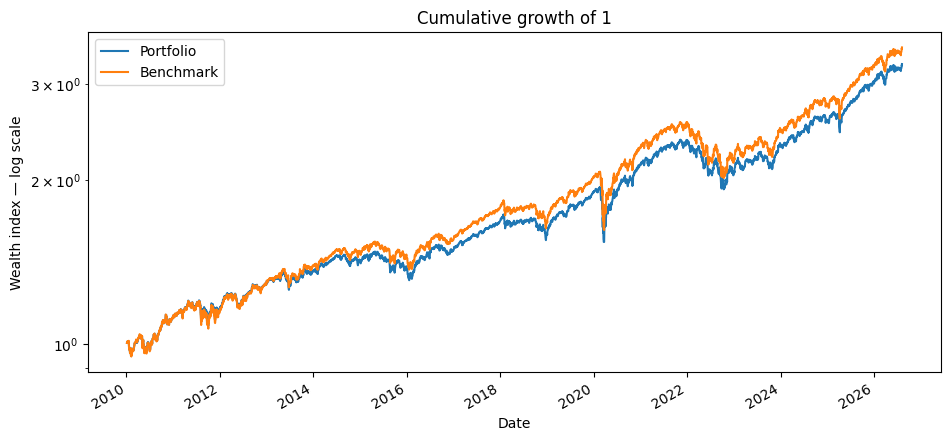

In [8]:
# ============================================================
# 5. PORTFOLIO OVERVIEW
# ============================================================

rp = engine.portfolio_returns
rb = engine.benchmark_returns
active = (rp - rb).rename("active_return")

overview = pd.Series({
    "sample_start": rp.index.min(),
    "sample_end": rp.index.max(),
    "observations": len(rp),
    "cumulative_portfolio_return": (1 + rp).prod() - 1,
    "cumulative_benchmark_return": (1 + rb).prod() - 1,
    "cumulative_active_difference": ((1 + rp).prod() - 1) - ((1 + rb).prod() - 1),
    "annualized_portfolio_volatility": rp.std(ddof=0) * np.sqrt(252),
    "annualized_benchmark_volatility": rb.std(ddof=0) * np.sqrt(252),
    "annualized_tracking_error": active.std(ddof=0) * np.sqrt(252),
}, name="portfolio_overview")
display(overview.to_frame())

wealth = pd.DataFrame({"Portfolio": (1 + rp).cumprod(), "Benchmark": (1 + rb).cumprod()})
ax = wealth.plot(figsize=(11, 5), logy=True, title="Cumulative growth of 1")
ax.set_ylabel("Wealth index — log scale")
plt.show()

## 6. Absolute multi-period performance attribution

Attribution is performed at the **native return frequency** and linked geometrically.

,linked_return_contribution,pct_of_cumulative_portfolio_return
Ticker,,
VT,1.366278,0.602260
IEF,0.220637,0.097258
VNQ,0.181348,0.079939
GLD,0.177681,0.078322
LQD,0.154475,0.068093
HYG,0.144246,0.063584
BIL,0.015831,0.006978
DBC,0.008088,0.003565


,geometric_asset_linking_check
cumulative_portfolio_return,2.268584
sum_linked_asset_contributions,2.268584
linking_error,0.000000
attribution_basis,"native frequency, geometrically linked (exact)"


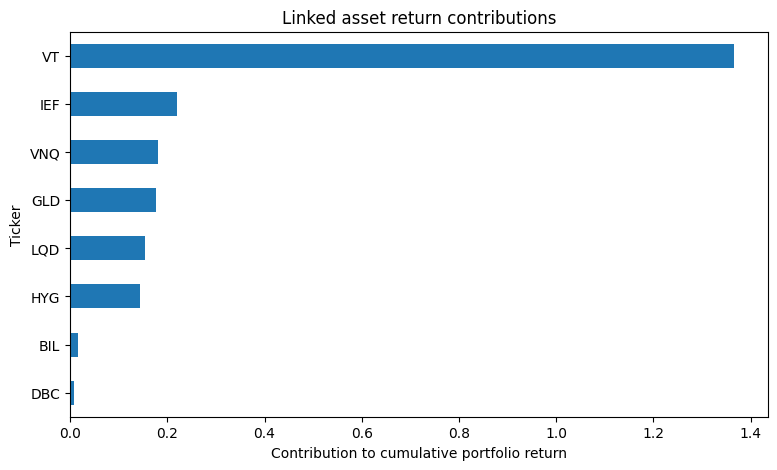


ASSET CLASS — LINKED PERFORMANCE CONTRIBUTION


,linked_return_contribution
Asset Class,
Equity,1.366278
Real Assets,0.367117
Credit,0.298721
Rates,0.220637
Cash,0.015831



RISK SLEEVE — LINKED PERFORMANCE CONTRIBUTION


,linked_return_contribution
Risk Sleeve,
Growth,1.547626
Duration,0.375112
Diversifier,0.185769
Credit,0.144246
Liquidity,0.015831



REGION — LINKED PERFORMANCE CONTRIBUTION


,linked_return_contribution
Region,
Global,1.552047
US,0.716537



CURRENCY — LINKED PERFORMANCE CONTRIBUTION


,linked_return_contribution
Currency,
USD,2.268584


In [9]:
# ============================================================
# 6. ABSOLUTE PERFORMANCE ATTRIBUTION
# ============================================================

asset_perf, asset_perf_check = engine.linked_asset_performance(basis="native")
asset_perf = asset_perf.sort_values("linked_return_contribution", ascending=False)
display(asset_perf)
display(asset_perf_check.to_frame())

ax = asset_perf["linked_return_contribution"].sort_values().plot(kind="barh", figsize=(9, 5), title="Linked asset return contributions")
ax.set_xlabel("Contribution to cumulative portfolio return")
plt.show()

for level in classifications.columns:
    grouped = aggregate_attribution_by_level(asset_perf, classifications, level, columns=["linked_return_contribution"]).sort_values("linked_return_contribution", ascending=False)
    print(f"\n{level.upper()} — LINKED PERFORMANCE CONTRIBUTION")
    display(grouped)


## 7. Benchmark-relative performance attribution

### Primary result: exact native-frequency Brinson

Portfolio and benchmark weights are applied at every native-frequency return
observation. Therefore, **native-frequency BHB/BF attribution is the economic
ground truth for the realised strategy** and is the primary result below.

### Secondary result: coarser reporting view

A monthly Brinson view is also reported because monthly attribution is common in
investment reporting. It compounds asset returns first and then applies
beginning-of-period weights. When that operation changes the effective
rebalancing convention, its cumulative portfolio and benchmark returns need not
equal the native-frequency realised strategy.

The notebook therefore reports the approximation gap explicitly. A monthly view
that differs from the realised strategy is labelled **approximate**, even if its
own Brinson effects reconcile perfectly internally.



EXACT NATIVE BF — Asset Class


,linked_effect,pct_of_cumulative_active_return
interaction_effect,-0.021654,0.090860
selection_effect,-0.046916,0.196859
allocation_effect,-0.169751,0.712281


,carino_linking_check
cumulative_portfolio_return,2.268584
cumulative_benchmark_return,2.506905
cumulative_active_return,-0.238320
sum_linked_effects,-0.238320
linking_error,-0.000000
attribution_basis,"native frequency, Carino-linked (exact)"



EXACT NATIVE BHB — Asset Class


,linked_effect,pct_of_cumulative_active_return
interaction_effect,-0.021654,0.090860
selection_effect,-0.046916,0.196859
allocation_effect,-0.169751,0.712281


...

,linked_effect,pct_of_cumulative_active_return
interaction_effect,-0.022265,0.093426
selection_effect,-0.030921,0.129745
allocation_effect,-0.185134,0.776829


,carino_linking_check
cumulative_portfolio_return,2.268584
cumulative_benchmark_return,2.506905
cumulative_active_return,-0.238320
sum_linked_effects,-0.238320
linking_error,-0.000000
attribution_basis,"native frequency, Carino-linked (exact)"



EXACT NATIVE BHB — Risk Sleeve


,linked_effect,pct_of_cumulative_active_return
interaction_effect,-0.022265,0.093426
selection_effect,-0.030921,0.129745
allocation_effect,-0.185134,0.776829


,carino_linking_check
cumulative_portfolio_return,2.268584
cumulative_benchmark_return,2.506905
cumulative_active_return,-0.238320
sum_linked_effects,-0.238320
linking_error,-0.000000
attribution_basis,"native frequency, Carino-linked (exact)"


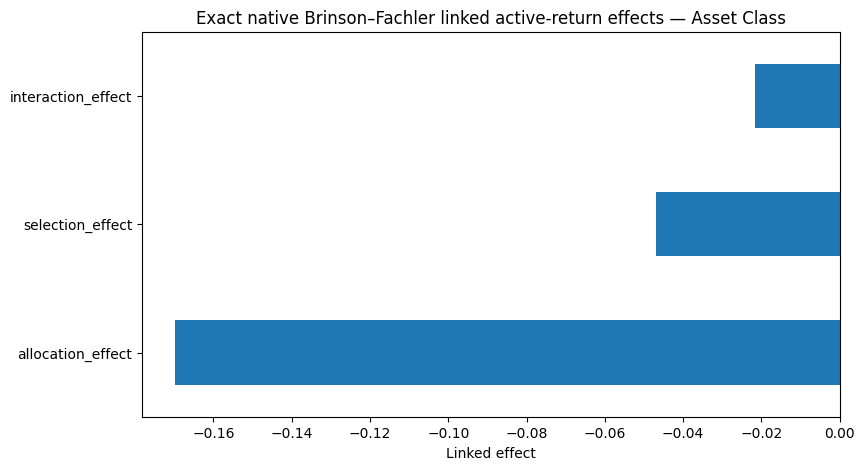


SECONDARY REPORTING VIEW BF — Asset Class (ME)


,linked_effect,pct_of_cumulative_active_return
interaction_effect,-0.019596,0.085996
selection_effect,-0.041260,0.181065
allocation_effect,-0.167017,0.732939


,carino_linking_check
cumulative_portfolio_return,2.187479
cumulative_benchmark_return,2.415352
cumulative_active_return,-0.227873
sum_linked_effects,-0.227873
linking_error,0.000000
weight_convention,beginning-of-period
attribution_basis,compounded to 'ME' — secondary reporting view
native_weight_semantics,weights applied at every native-frequency obse...
exact_native_cumulative_portfolio_return,2.268584
exact_native_cumulative_benchmark_return,2.506905



SECONDARY REPORTING VIEW BHB — Asset Class (ME)


,linked_effect,pct_of_cumulative_active_return
interaction_effect,-0.019596,0.085996
selection_effect,-0.041260,0.181065
allocation_effect,-0.167017,0.732939


...


SECONDARY REPORTING VIEW BHB — Risk Sleeve (ME)


,linked_effect,pct_of_cumulative_active_return
interaction_effect,-0.021008,0.092191
selection_effect,-0.030569,0.134148
allocation_effect,-0.176297,0.773661


,carino_linking_check
cumulative_portfolio_return,2.187479
cumulative_benchmark_return,2.415352
cumulative_active_return,-0.227873
sum_linked_effects,-0.227873
linking_error,0.000000
weight_convention,beginning-of-period
attribution_basis,compounded to 'ME' — secondary reporting view
native_weight_semantics,weights applied at every native-frequency obse...
exact_native_cumulative_portfolio_return,2.268584
exact_native_cumulative_benchmark_return,2.506905



REPORTING-VIEW APPROXIMATION DIAGNOSTIC


reporting_rule  reporting_view_portfolio_return  exact_native_portfolio_return  portfolio_gap  reporting_view_benchmark_return  \
level       method                                                                                                                                  
Asset Class BF                 ME                         2.187479                       2.268584      -0.081106                         2.415352   
            BHB                ME                         2.187479                       2.268584      -0.081106                         2.415352   
Risk Sleeve BF                 ME                         2.187479                       2.268584      -0.081106                         2.415352   
            BHB                ME                         2.187479                       2.268584      -0.081106                         2.415352   

                    exact_native_benchmark_return  benchmark_gap  reporting_view_active_return  exact_native_active_return  active_gap  max_abs_gap  \
level       method                                                                                                                                    
Asset Class BF                           2.506905      -0.091553                     -0.227873                   -0.238320    0.010447     0.091553   
            BHB                          2.506905      -0.091553                     -0.227873                   -0.238320    0.010447     0.091553   
Risk Sleeve BF                           2.506905      -0.091553                     -0.227873                   -0.238320    0.010447     0.091553   
            BHB                          2.506905      -0.091553                     -0.227873                   -0.238320    0.010447     0.091553   

                    reporting_view_is_exact                                             status  
level       method                                                                              
Asset Class BF                        False  approximate relative to native-frequency reali...  
            BHB                       False  approximate relative to native-frequency reali...  
Risk Sleeve BF                        False  approximate relative to native-frequency reali...  
            BHB                       False  approximate relative to native-frequency reali...

In [10]:
# ============================================================
# 7. BRINSON ATTRIBUTION
# ============================================================

# ------------------------------------------------------------------
# A. PRIMARY: exact native-frequency attribution
# ------------------------------------------------------------------
brinson_native_outputs = {}

for level in classifications.columns[:2]:
    for method in ["BF", "BHB"]:
        detailed, summary, check = engine.brinson(
            level=level,
            method=method,
            basis="native",
        )
        brinson_native_outputs[(level, method)] = (detailed, summary, check)

        print(f"\nEXACT NATIVE {method} — {level}")
        display(summary.sort_values("linked_effect", ascending=False))
        display(check.to_frame())

# Primary chart: exact native Brinson-Fachler by Asset Class
if ("Asset Class", "BF") in brinson_native_outputs:
    bf_native_summary = brinson_native_outputs[("Asset Class", "BF")][1]
    ax = bf_native_summary["linked_effect"].sort_values().plot(
        kind="barh",
        figsize=(9, 5),
        title="Exact native Brinson–Fachler linked active-return effects — Asset Class",
    )
    ax.set_xlabel("Linked effect")
    plt.show()


# ------------------------------------------------------------------
# B. SECONDARY: reporting-frequency approximation
# ------------------------------------------------------------------
brinson_reporting_outputs = {}
gap_rows = []

for level in classifications.columns[:2]:
    for method in ["BF", "BHB"]:
        detailed, summary, check = engine.brinson(
            level=level,
            rule=REPORTING_RULE,
            method=method,
            basis="period",
        )
        brinson_reporting_outputs[(level, method)] = (detailed, summary, check)

        gap_rows.append({
            "level": level,
            "method": method,
            "reporting_rule": REPORTING_RULE,
            "reporting_view_portfolio_return": check["cumulative_portfolio_return"],
            "exact_native_portfolio_return": check["exact_native_cumulative_portfolio_return"],
            "portfolio_gap": check["period_basis_portfolio_gap"],
            "reporting_view_benchmark_return": check["cumulative_benchmark_return"],
            "exact_native_benchmark_return": check["exact_native_cumulative_benchmark_return"],
            "benchmark_gap": check["period_basis_benchmark_gap"],
            "reporting_view_active_return": check["cumulative_active_return"],
            "exact_native_active_return": check["exact_native_cumulative_active_return"],
            "active_gap": check["period_basis_active_gap"],
            "max_abs_gap": check["period_basis_max_abs_gap"],
            "reporting_view_is_exact": check["reporting_view_is_exact"],
            "status": check["reporting_view_status"],
        })

        print(f"\nSECONDARY REPORTING VIEW {method} — {level} ({REPORTING_RULE})")
        display(summary.sort_values("linked_effect", ascending=False))
        display(check.to_frame())

brinson_reporting_gap = pd.DataFrame(gap_rows).set_index(["level", "method"])

print("\nREPORTING-VIEW APPROXIMATION DIAGNOSTIC")
display(brinson_reporting_gap)

# Keep a single check object available for the executive summary.
brinson_reporting_check = brinson_reporting_outputs[
    ("Asset Class", "BF")
][2] if ("Asset Class", "BF") in brinson_reporting_outputs else next(
    iter(brinson_reporting_outputs.values())
)[2]


## 8. Factor attribution

The regression decomposes expected portfolio return into factor contributions, intercept and residual, and decomposes variance into factor components plus residual variance.

,beta,mean_factor_return,expected_return_contribution,component_factor_variance
component,,,,
Equity_ex_cash,0.493626,0.000405,0.000200,0.000031
Duration_ex_cash,0.467818,0.000058,0.000027,0.000000
Credit_ex_rates,0.138538,0.000106,0.000015,0.000004
intercept_alpha,NaN,NaN,0.000060,0.000000
residual,NaN,NaN,-0.000000,0.000001


,factor_attribution_check
expected_portfolio_return,0.000302
sum_expected_return_contributions,0.000302
return_additivity_error,0.000000
portfolio_variance,0.000035
explained_factor_variance,0.000034
residual_variance,0.000001
sum_variance_components,0.000035
variance_reconciliation_error,0.000000
weighted_R2,0.967048
attribution_basis,native frequency


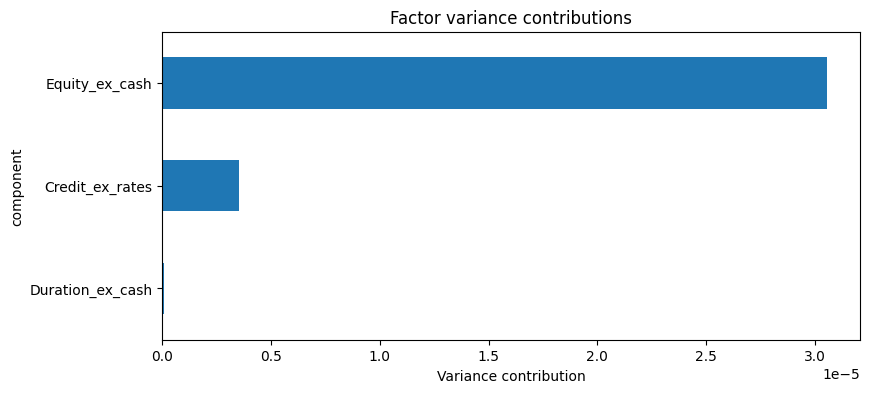

In [11]:
# ============================================================
# 8. FACTOR ATTRIBUTION
# ============================================================

factor_table, factor_check, factor_residual = engine.factor_attribution(basis="native")
display(factor_table)
display(factor_check.to_frame())

factor_plot = factor_table.loc[[i for i in factor_table.index if i not in {"intercept_alpha", "residual"}], "component_factor_variance"].sort_values()
ax = factor_plot.plot(kind="barh", figsize=(9, 4), title="Factor variance contributions")
ax.set_xlabel("Variance contribution")
plt.show()

## 9. Volatility attribution

,weight,component_variance,component_volatility,pct_of_portfolio_volatility
Ticker,,,,
VT,0.420000,0.000019,0.003596,0.678092
GLD,0.070000,0.000002,0.000445,0.083819
VNQ,0.050000,0.000002,0.000357,0.067264
IEF,0.180000,0.000002,0.000303,0.057075
LQD,0.100000,0.000001,0.000282,0.053154
HYG,0.080000,0.000001,0.000220,0.041559
DBC,0.050000,0.000001,0.000101,0.019130
BIL,0.050000,-0.000000,-0.000000,-0.000092


,volatility_attribution_check
portfolio_variance,0.000028
portfolio_volatility,0.005304
sum_component_variance,0.000028
variance_additivity_error,0.000000
sum_component_volatility,0.005304
volatility_additivity_error,0.000000


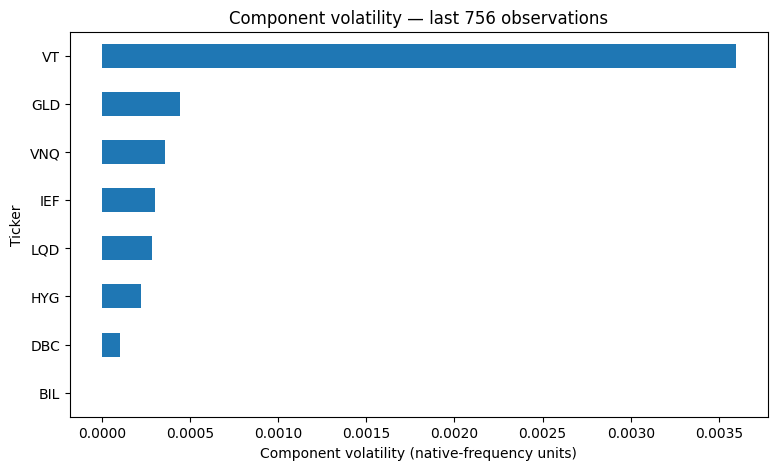

In [12]:
# ============================================================
# 9. VOLATILITY ATTRIBUTION
# ============================================================

vol_table, vol_check = engine.volatility(lookback=RISK_LOOKBACK)
vol_table = vol_table.sort_values("component_volatility", ascending=False)
display(vol_table)
display(vol_check.to_frame())
ax = vol_table["component_volatility"].sort_values().plot(kind="barh", figsize=(9, 5), title=f"Component volatility — last {RISK_LOOKBACK} observations")
ax.set_xlabel("Component volatility (native-frequency units)")
plt.show()

## 10. Tracking-error attribution

,portfolio_weight,benchmark_weight,active_weight,component_tracking_error_variance,component_tracking_error,pct_of_tracking_error
Ticker,,,,,,
VT,0.420000,0.500000,-0.080000,0.000000,0.000565,0.773255
DBC,0.050000,0.020000,0.030000,0.000000,0.000150,0.204988
GLD,0.070000,0.050000,0.020000,0.000000,0.000057,0.077946
IEF,0.180000,0.200000,-0.020000,0.000000,0.000017,0.023185
BIL,0.050000,0.030000,0.020000,0.000000,0.000000,0.000310
LQD,0.100000,0.100000,0.000000,-0.000000,-0.000000,-0.000000
VNQ,0.050000,0.050000,0.000000,-0.000000,-0.000000,-0.000000
HYG,0.080000,0.050000,0.030000,-0.000000,-0.000058,-0.079684


,tracking_error_attribution_check
tracking_error_variance,0.000001
tracking_error,0.000731
sum_component_TE_variance,0.000001
TE_variance_additivity_error,0.000000
sum_component_tracking_error,0.000731
tracking_error_additivity_error,0.000000


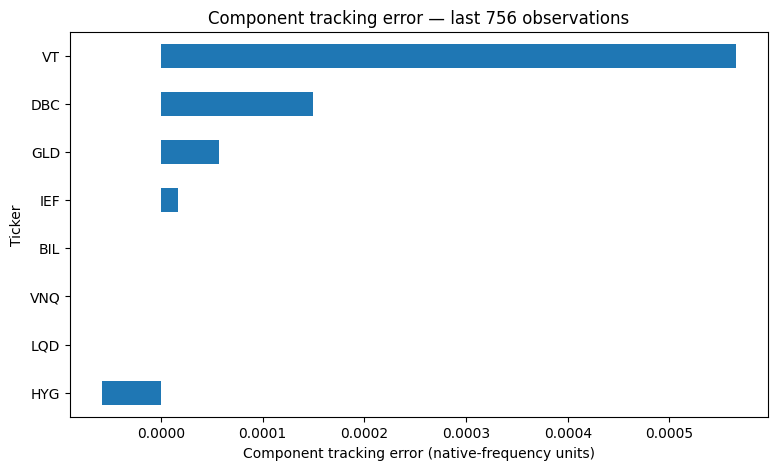

In [13]:
# ============================================================
# 10. TRACKING-ERROR ATTRIBUTION
# ============================================================

te_table, te_check = engine.tracking_error(lookback=RISK_LOOKBACK)
te_table = te_table.sort_values("component_tracking_error", ascending=False)
display(te_table)
display(te_check.to_frame())
ax = te_table["component_tracking_error"].sort_values().plot(kind="barh", figsize=(9, 5), title=f"Component tracking error — last {RISK_LOOKBACK} observations")
ax.set_xlabel("Component tracking error (native-frequency units)")
plt.show()

## 11. Expected Shortfall attribution

Historical ES is decomposed with the **same portfolio-tail weights for every asset contribution**, preserving additivity.

,weight,component_ES,component_ES_pct
Ticker,,,
VT,0.420000,"9,633.467782",0.657866
GLD,0.070000,"1,427.175101",0.097461
VNQ,0.050000,"1,041.596895",0.071130
IEF,0.180000,709.336991,0.048440
LQD,0.100000,696.821006,0.047586
HYG,0.080000,611.340310,0.041748
DBC,0.050000,533.842023,0.036456
BIL,0.050000,-10.060012,-0.000687


,expected_shortfall_attribution_check
confidence_level,0.975000
VaR,"10,553.635116"
Expected_Shortfall,"14,643.520096"
sum_component_ES,"14,643.520096"
additivity_error,-0.000000
tail_probability_mass,0.025000
positive_tail_weight_observations,19.000000


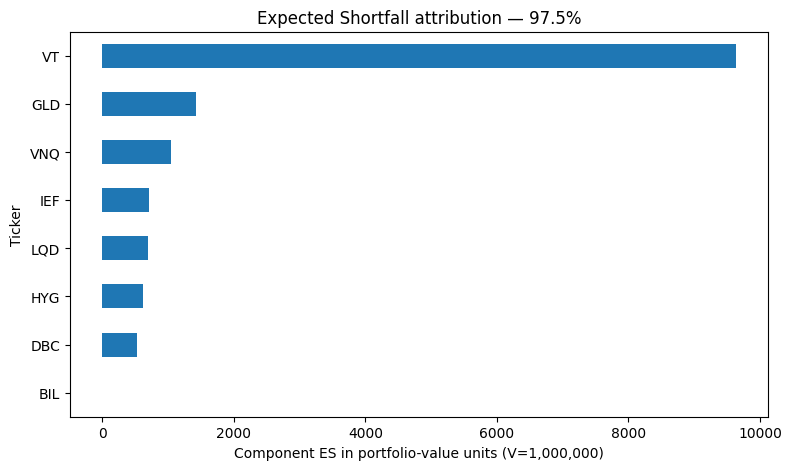

In [14]:
# ============================================================
# 11. EXPECTED SHORTFALL ATTRIBUTION
# ============================================================

es_table, es_check, es_tail_weights = engine.expected_shortfall(alpha=ES_ALPHA, lookback=RISK_LOOKBACK)
es_table = es_table.sort_values("component_ES", ascending=False)
display(es_table)
display(es_check.to_frame())
ax = es_table["component_ES"].sort_values().plot(kind="barh", figsize=(9, 5), title=f"Expected Shortfall attribution — {ES_ALPHA:.1%}")
ax.set_xlabel(f"Component ES in portfolio-value units (V={PORTFOLIO_VALUE:,.0f})")
plt.show()

## 12. Maximum-drawdown attribution

,drawdown_contribution,pct_of_max_drawdown
Ticker,,
VT,0.149935,0.722633
VNQ,0.023292,0.112260
HYG,0.018209,0.087762
DBC,0.012814,0.061758
LQD,0.011349,0.054699
GLD,0.002178,0.010497
BIL,-0.000111,-0.000534
IEF,-0.010183,-0.049076


,max_drawdown_attribution_check
peak_date,2020-02-19 00:00:00
trough_date,2020-03-23 00:00:00
maximum_drawdown,0.207485
sum_drawdown_contributions,0.207485
additivity_error,0.000000
episode_cumulative_return,-0.207485


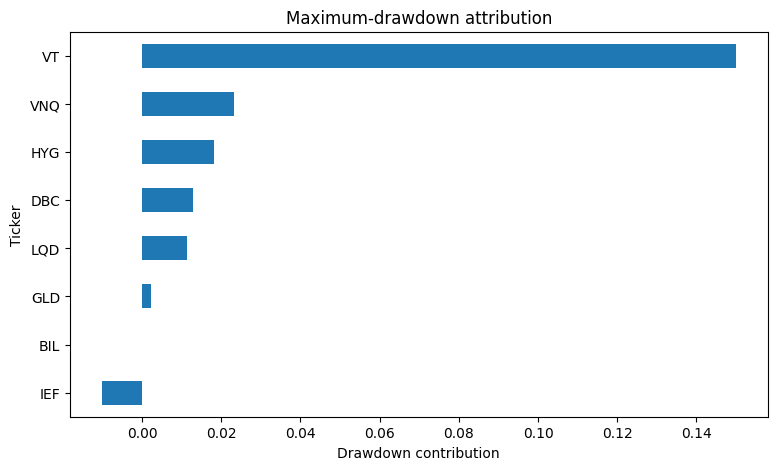

In [15]:
# ============================================================
# 12. MAXIMUM-DRAWDOWN ATTRIBUTION
# ============================================================

dd_table, dd_check = engine.max_drawdown()
dd_table = dd_table.sort_values("drawdown_contribution", ascending=False)
display(dd_table)
display(dd_check.to_frame())
ax = dd_table["drawdown_contribution"].sort_values().plot(kind="barh", figsize=(9, 5), title="Maximum-drawdown attribution")
ax.set_xlabel("Drawdown contribution")
plt.show()

## 13. Optional manual stress-period attribution

In [16]:
# ============================================================
# 13. OPTIONAL STRESS PERIOD
# ============================================================

if STRESS_START is not None and STRESS_END is not None:
    stress_table, stress_check = engine.stress_period(STRESS_START, STRESS_END)
    print(f"Stress period: {STRESS_START} -> {STRESS_END}")
    display(stress_table.sort_values("stress_period_return_contribution"))
    display(stress_check.to_frame())
else:
    print("Manual stress period skipped. Set STRESS_START and STRESS_END in Configuration to enable it.")

Manual stress period skipped. Set STRESS_START and STRESS_END in Configuration to enable it.



## 14. Release gate

The gate now checks three distinct things:

1. mathematical additivity/reconciliation;
2. meaning-level agreement of **native-frequency Brinson** with independently
   calculated realised portfolio and benchmark returns;
3. semantic honesty of the coarser reporting view: if its cumulative return
   differs from the native-frequency strategy, it must be labelled
   **approximate**, not exact.

The magnitude of the monthly approximation gap is surfaced as a diagnostic and
does not itself invalidate the engine.


In [17]:
# ============================================================
# 14. RELEASE GATE
# ============================================================

gate, release_passed = release_gate(asset_returns, portfolio_weights, benchmark_weights, classifications, factor_returns)
display(gate)
status = "PASSED" if release_passed else "FAILED"
display(Markdown(f"## RELEASE GATE: **{status}**"))
if not release_passed:
    raise RuntimeError("Release gate failed. Review the failing block(s) before using results.")

value  tolerance  passed
block                              kind                                   
input_contracts                    meaning     0.000000   0.000000    True
linked_performance                 identity    0.000000   0.000000    True
                                   meaning     0.000000   0.000000    True
volatility                         identity    0.000000   0.000000    True
expected_shortfall                 identity    0.000000   0.000000    True
max_drawdown                       identity    0.000000   0.000000    True
tracking_error                     identity   -0.000000   0.000000    True
brinson_native                     identity   -0.000000   0.000000    True
brinson_native_portfolio           meaning     0.000000   0.000000    True
brinson_native_benchmark           meaning     0.000000   0.000000    True
brinson_period_approximation_gap   diagnostic  0.091553        NaN    True
brinson_period_reporting_semantics meaning     0.000000   0.000000    True
brinson_vectorised_vs_reference    meaning     0.000000   0.000000    True
factor_return                      identity    0.000000   0.000000    True
factor_variance                    identity    0.000000   0.000000    True

## RELEASE GATE: **PASSED**

## 15. Executive output

Compact output suitable for discussing the project without walking through every implementation detail.

In [18]:
# ============================================================
# 15. EXECUTIVE SUMMARY
# ============================================================

top_perf = asset_perf["linked_return_contribution"].idxmax()
top_es = es_table["component_ES"].idxmax()
top_vol = vol_table["component_volatility"].idxmax()
top_te = te_table["component_tracking_error"].idxmax()

executive = pd.Series({
    "cumulative_portfolio_return": asset_perf_check["cumulative_portfolio_return"],
    "cumulative_benchmark_return": float((1 + engine.benchmark_returns).prod() - 1),
    "factor_weighted_R2": factor_check["weighted_R2"],
    "top_performance_contributor": top_perf,
    "top_volatility_contributor": top_vol,
    "top_tracking_error_contributor": top_te,
    "top_ES_contributor": top_es,
    "ES_confidence": ES_ALPHA,
    "portfolio_ES": es_check["Expected_Shortfall"],
    "maximum_drawdown": dd_check["maximum_drawdown"],
    "brinson_primary_basis": "native-frequency exact",
    "secondary_reporting_rule": REPORTING_RULE,
    "secondary_BF_max_abs_approximation_gap": brinson_reporting_check["period_basis_max_abs_gap"],
    "secondary_BF_reporting_view_is_exact": brinson_reporting_check["reporting_view_is_exact"],
    "release_gate_passed": release_passed,
}, name="executive_summary")
display(executive.to_frame())
print("\nNotebook completed successfully.")

,executive_summary
cumulative_portfolio_return,2.268584
cumulative_benchmark_return,2.506905
factor_weighted_R2,0.967048
top_performance_contributor,VT
top_volatility_contributor,VT
top_tracking_error_contributor,VT
top_ES_contributor,VT
ES_confidence,0.975000
portfolio_ES,"14,643.520096"
maximum_drawdown,0.207485



Notebook completed successfully.


---

### Scope boundary for this release

The current notebook deliberately stops at the stable v1 core. Native-frequency Brinson is the exact benchmark-relative result; coarser period Brinson is retained only as an explicitly diagnosed reporting view. Future work can add, separately:

- security-level factor risk models and regularised factor selection;
- factor-plus-residual Expected Shortfall attribution;
- currency attribution;
- fixed-income carry / rolldown / curve / spread attribution;
- Greeks-based P&L explain;
- rolling attribution and formal uncertainty estimates.

Those extensions are **not required to run or defend the present engine**.